In [1]:
import os, sys 
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from typing import Optional, Union, List, Tuple, Dict
import time
import copy

current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../"))
project_root
sys.path.append(project_root)

# from vllm.v1.core.sched.step_estimator import StepStats
# from vllm.v1.core.sched.step_estimator.models.light_gradient_boost_machine import (
#     LightGradientBoostMachine,
# )
# from vllm.v1.core.sched.step_estimator.models.utils import transform_features

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

def train_test_split_2(X, y, colx, test_size=0.2, random_state=None):
    """
    Split X and y into train/test sets such that every unique value in `colx`
    appears in both train and test sets.
    """
    if isinstance(X, pd.DataFrame):
        df = X.copy()
        df["_y"] = y
    else:
        raise ValueError("X must be a pandas DataFrame")

    rng = np.random.default_rng(random_state)
    train_idx = []
    test_idx = []

    for val in df[colx].unique():
        group_indices = df.index[df[colx] == val].to_numpy()
        # if group has only one sample, duplicate it into both sets
        if len(group_indices) == 1:
            i = group_indices[0]
            train_idx.append(i)
            test_idx.append(i)
            continue
        # otherwise, split the group itself
        group_train, group_test = train_test_split(
            group_indices, test_size=test_size, random_state=random_state
        )
        # ensure at least one from this group in both sets
        if len(group_train) == 0:
            group_train = group_test[:1]
        if len(group_test) == 0:
            group_test = group_train[:1]
        train_idx.extend(group_train)
        test_idx.extend(group_test)

    # ensure unique and no overlap
    train_idx = np.unique(train_idx)
    test_idx = np.unique(test_idx)
    # remove overlaps if any accidental duplication happened
    overlap = np.intersect1d(train_idx, test_idx)
    if len(overlap) > 0:
        test_idx = np.setdiff1d(test_idx, overlap)

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx] if hasattr(y, "loc") else np.asarray(y)[train_idx]
    y_test = y.loc[test_idx] if hasattr(y, "loc") else np.asarray(y)[test_idx]

    return X_train, X_test, y_train, y_test

In [13]:
paths = [
    "../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.9.json",
    "../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.5.json",
    "../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.6.json", 
    "../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.8.json", 
    "../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.6.json",
    "../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.7.json",
    "../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.8.json",
    "../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.5.json",
    "../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.7.json",  
    "../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.9.json", 
]

def read_data(paths: List[str], included_features): 

    df = pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)
    df["full_progress"] = (df["num_denoise_ran"] + 1) / df["output_length"]
    df["full_unmask_progress"] = df["num_unmasked_tokens"] / df["output_length"]
    df["full_cur_unmask_progress"] = df["num_cur_unmasked_tokens"] / df["output_length"]
    df["block_progress"] = df["block"] / (df["output_length"] // df["block_size"])
    df["block_unmask_progress"] = df["block_num_unmasked_tokens"] / df["block_size"]

    df = df.sort_values(["id", "full_unmask_progress"])
    # for span in [5, 10, 20]:
    #     df[f"ewma_{span}"] = (
    #         df.groupby("id")["full_unmask_progress"]
    #         .apply(lambda s: s.ewm(span=span, adjust=False).mean())
    #         .reset_index(level=0, drop=True)
    #     )

    def apply_confidences_statistic(conf_list, d = 4, base = 5000, alpha = 1): 
        stats_dict = {}
        L = len(conf_list)
        stats_dict["mean_confidences"] = np.mean(conf_list)
        stats_dict["min_confidences"] = np.min(conf_list)
        q25, q50, q75 = np.percentile(conf_list, [25, 50, 75])
        stats_dict["median_confidences"] = q50
        stats_dict["lower_quartile_confidences"] = q25
        stats_dict["higher_quartile_confidences"] = q75
        
        # positions array reused for all i
        pos = np.arange(L, dtype=float)

        # # precompute denominators for sin/cos exponents (tiny d, so loop is cheap)
        # for i in range(d):
        #     if i % 2 == 0:
        #         denom = base ** (i / d)
        #         pos_encoding = np.sin(pos / denom)
        #     else:
        #         denom = base ** ((i - 1) / d)
        #         pos_encoding = np.cos(pos / denom)

        #     conf_weighted = conf_list * np.exp(alpha * pos_encoding)
        #     stats_dict[f"mean_pos_conf_{i}"] = conf_weighted.mean()
            
        return stats_dict

    df_stats = df["confidences"].apply(apply_confidences_statistic).apply(pd.Series) 
    df = pd.concat([df, df_stats], axis=1)

    # Compute min and max per id
    agg_stats = (
        df.groupby("id")["cur_tokens_unmasked"]
        .apply(lambda lists: [t for sub in lists for t in sub])  # flatten
        .apply(lambda x: pd.Series({
            "min_cur_token": min(x),
            "max_cur_token": max(x)
        }))
    )

    # Merge back into original df
    df = df.merge(agg_stats, on="id", how="left")

    # def apply_unmasked_stats(row): 
    #     index_list = np.array(row["cur_tokens_unmasked"]) - row["min_cur_token"]
    #     conf_list = row["confidences"]
    #     threshold = row["confidence_threshold"]
    #     pending_set = set()
    #     half_pending_set = set()
    #     for i in index_list: 
    #         for j in range(1, min(4, row["output_length"] - i + 1)): 
    #             if (i + j) in pending_set: 
    #                 continue 
    #             if (threshold - 0.1 <= conf_list[i+j]) and (conf_list[i+j] <= threshold): 
    #                 pending_set.add(i+j) 
    #             elif (conf_list[i+j] <= threshold): 
    #                 if i+j in half_pending_set: 
    #                     half_pending_set.remove(i+j) 
    #                     pending_set.add(i+j) 
    #                 else: 
    #                     half_pending_set.add(i+j) 

    #     pending_2 = 0
    #     high_add = 1
    #     low_add = 0.5
    #     back_add = 0.3
    #     for i in index_list: 
    #         for j in range(1, min(4, row["output_length"] - i + 1)):
    #             if (threshold - 0.1 <= conf_list[i+j]) and (conf_list[i+j] <= threshold): 
    #                 pending_2 += high_add
    #             elif (conf_list[i+j] <= threshold):  
    #                 pending_2 += low_add    
    #         if (i > 1) and (conf_list[i-1] <= threshold): 
    #                 pending_2 += back_add 
    #         if (i > 2) and (conf_list[i-2] <= threshold):  
    #                 pending_2 += back_add       
        
    #     pending = len(pending_set) + 0.5 * len(half_pending_set)

    #     return pd.Series({"pending": pending, "pending_2": pending_2})


    # df[["pending", "pending_2"]] = df.apply(apply_unmasked_stats, axis = 1)

    # def apply_stateful_unmasked_stats(group): 
    #     # 4 layers of state shared across rows in this group
    #     layered_set = [set(), set(), set(), set()]

    #     potential_vals = []

    #     for _, row in group.iterrows():
    #         # --- compute pending / half-pending for this row ---
    #         index_list = np.array(row["cur_tokens_unmasked"]) - row["min_cur_token"]
    #         conf_list = row["confidences"]
    #         threshold = row["confidence_threshold"]

    #         pending_set = set()
    #         half_pending_set = set()

    #         for i in index_list: 
    #             for j in range(1, min(4, row["output_length"] - i + 1)): 
    #                 idx = i + j
    #                 if idx in pending_set:
    #                     continue
    #                 if threshold - 0.1 <= conf_list[idx] <= threshold:
    #                     pending_set.add(idx)
    #                 elif conf_list[idx] <= threshold:
    #                     if idx in half_pending_set:
    #                         half_pending_set.remove(idx)
    #                         pending_set.add(idx)
    #                     else:
    #                         half_pending_set.add(idx)

    #         # --- update layered_set safely ---
    #         for level in range(3, -1, -1):
    #             to_remove = set()
    #             to_promote = set()

    #             for x in list(layered_set[level]):  # iterate on a snapshot
    #                 if conf_list[x] >= threshold:
    #                     # no longer pending at all
    #                     to_remove.add(x)
    #                 elif x in pending_set and level < 3:
    #                     # still under threshold AND currently pending: promote
    #                     to_promote.add(x)

    #             # apply removals and promotions
    #             layered_set[level] -= to_remove
    #             layered_set[level] -= to_promote
    #             if level < 3:
    #                 layered_set[level + 1].update(to_promote)

    #         # OPTIONAL: new pending entries enter layer 0 if not already in any layer
    #         for x in pending_set:
    #             if not any(x in s for s in layered_set):
    #                 layered_set[0].add(x)

    #         # --- compute potential for this row ---
    #         potential = (
    #             np.exp(0.5) * len(half_pending_set)
    #             + np.exp(1) * len(layered_set[0])
    #             + np.exp(2) * len(layered_set[1])
    #             + np.exp(3) * len(layered_set[2])
    #             + np.exp(4) * len(layered_set[3])
    #         )
    #         potential_vals.append(potential)

    #     group["potential"] = potential_vals
    #     return group

    # df = df.sort_values(["id", "full_unmask_progress"]).groupby("id", group_keys=False).apply(apply_stateful_unmasked_stats)

    # Compute targets
    final_denoise = df.groupby("id")["num_denoise_ran"].transform("max")
    df["denoise_ratio"] = (final_denoise - df["num_denoise_ran"]) / df["output_length"]

    X = df[included_features + ["output_length", "num_unmasked_tokens"]]
    y = df["denoise_ratio"]

    X["confidence_threshold"] = X["confidence_threshold"].apply(float)

    X_train, X_test, y_train, y_test = train_test_split_2(X, y, "confidence_threshold", test_size = 0.2, random_state=42)

    return df, X_train, X_test, y_train, y_test


In [14]:
def percentage_metrics(x, y): 
    numerator = np.abs(x - y).sum() 
    denominator = np.abs(x).sum()
    return numerator / denominator

In [15]:
included_features_T = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    # "ewma_5", 
    # "ewma_10", 
    # "ewma_20", 
]

df, X_train, X_test, y_train, y_test = read_data(paths, included_features_T)

/tmp/ipykernel_3389855/1000676141.py:190: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["confidence_threshold"] = X["confidence_threshold"].apply(float)


In [16]:
def train_experiment(model, X_train, X_test, y_train, y_test, included_features): 

    # Training
    model.fit(X_train[included_features], y_train)

    start_time = time.time()
    predictions = model.predict(X_test[included_features])
    end_time = time.time()
    print(f"Inferrence: Make {len(X_test)} predictions in {(end_time - start_time) * 1000} ms")

    pred_time = []
    for i in range(min(500, len(X_test))):
        start_time = time.time()
        _ = model.predict(X_test[included_features].iloc[i:i+10])
        pred_time.append(time.time() - start_time)
    print(f"Average prediction time per sample (batch of 10): {float(np.mean(pred_time)) * 1000} ms")

    rmse_ratio = root_mean_squared_error(y_test, predictions)
    r2_ratio = r2_score(y_test, predictions)
    percentage_ratio = percentage_metrics(y_test, predictions)

    y_test_steps = y_test * X_test["output_length"]
    y_pred_steps = predictions * X_test["output_length"]


    rmse_steps = root_mean_squared_error(y_test_steps, y_pred_steps)
    r2_steps = r2_score(y_test_steps, y_pred_steps)
    percentage_steps = percentage_metrics(y_test_steps, y_pred_steps)

    print(f"RMSE (steps): {rmse_steps:.4f}")
    print(f"R^2   (steps): {r2_steps:.4f}")
    print(f"Percentage (steps): {percentage_steps:.4f}")
    print(f"RMSE (ratio): {rmse_ratio:.4f}")
    print(f"R^2   (ratio): {r2_ratio:.4f}")
    print(f"Percentage (ratio): {percentage_ratio:.4f}")

    title_suffix = "80-20"
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, predictions, alpha=0.3)
    plt.xlabel("Actual Denoise Ratio")
    plt.ylabel("Predicted Denoise Ratio")
    plt.title(f"Predicted vs Actual Denoise Ratio {title_suffix}")
    lim_lo = float(min(y_test.min(), predictions.min()))
    lim_hi = float(max(y_test.max(), predictions.max()))
    plt.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--")
    plt.tight_layout()
    plt.savefig("denoise_ratio_prediction.png", dpi=300)

    # Steps vs num_unmasked_tokens
    test_num_unmasked = X_test["num_unmasked_tokens"]
    plt.figure(figsize=(6, 5))
    plt.scatter(test_num_unmasked, y_test_steps, alpha=0.3, label="Actual")
    plt.scatter(test_num_unmasked, y_pred_steps, alpha=0.3, label="Predicted")
    plt.xlabel("Num Unmasked Tokens")
    plt.ylabel("Num Denoise Steps Left")    
    plt.title(f"Predicted vs Actual Denoise Steps Left {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("denoise_steps_prediction.png", dpi=300)

def predict_benchmark(model, X_test, included_features): 
    pred_time = []
    for i in range(len(X_test)): 
        start_time = time.time()
        _ = model.predict(X_test[included_features].iloc[i:i+5])
        end_time = time.time() 
        pred_time.append((end_time - start_time) * 1000)
    print(f"Average prediction time per sample (single): {float(np.mean(pred_time))} ms")

Inferrence: Make 12100 predictions in 2.5742053985595703 ms
Average prediction time per sample (batch of 10): 3.4081435203552246 ms
RMSE (steps): 12.0168
R^2   (steps): 0.8258
Percentage (steps): 0.2100
RMSE (ratio): 0.0315
R^2   (ratio): 0.8382
Percentage (ratio): 0.2108


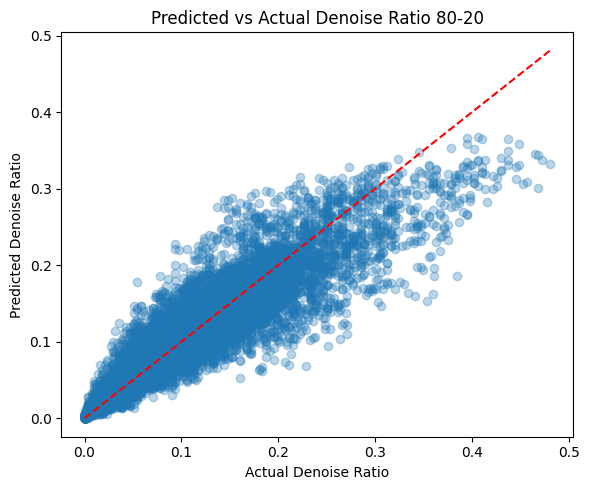

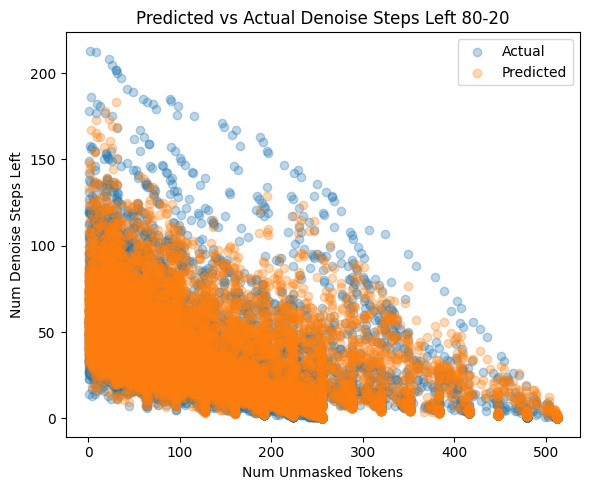

In [17]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    # n_estimators=200,
    # learning_rate=0.1,
    # num_leaves=64,
    verbose=-1,
)

train_experiment(model, X_train, X_test, y_train, y_test, included_features_T)

### DEFAULT BASELINE ==============================================================================================

Inferrence: Make 12100 predictions in 5.507230758666992 ms
Average prediction time per sample (batch of 10): 3.5895872116088867 ms
RMSE (steps): 8.8087
R^2   (steps): 0.9064
Percentage (steps): 0.1411
RMSE (ratio): 0.0238
R^2   (ratio): 0.9077
Percentage (ratio): 0.1458
Average prediction time per sample (single): 3.677870242063664 ms


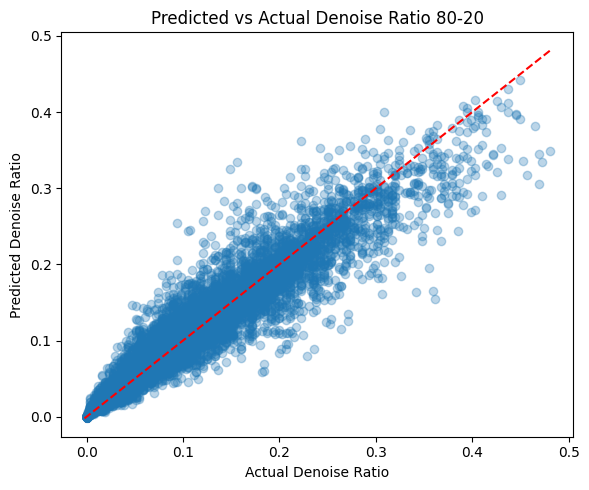

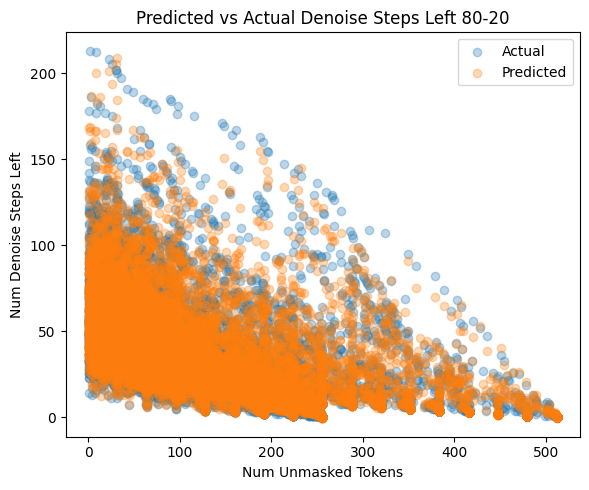

In [18]:
model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    # n_estimators=200,
    # learning_rate=0.1,
    # num_leaves=64,
    num_leaves = 800,
    verbose=-1,
)

train_experiment(model, X_train, X_test, y_train, y_test, included_features_T)
predict_benchmark(model, X_test, included_features_T)

### CURRENT STATE OF THE ART

In [10]:
class CaseModel: 
    def __init__(self, base_model, mapping, feature): 
        self.model = []
        self.mapping = mapping 
        for _ in range(len(mapping)): 
            self.model.append(copy.deepcopy(base_model))
        self.map_feature = feature
    
    def fit(self, X, y): 
        route_col = X[self.map_feature] 
        for key, idx in self.mapping.items(): 
            mask = np.isclose(route_col, key, atol=1e-8)
            Xi = X.loc[mask, :].to_numpy()
            yi = y.loc[mask].to_numpy()
            self.model[idx].fit(Xi, yi) 
    
    def predict(self, X): 
        preds = np.empty(len(X))
        route_col = X[self.map_feature]
        for key, idx in self.mapping.items(): 
            mask = np.isclose(route_col, key, atol=1e-8)
            Xi = X.loc[mask, :].to_numpy()
            if (len(Xi) == 0): 
                continue
            preds[mask] = self.model[idx].predict(Xi)
        return preds

/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Inferrence: Make 12100 predictions in 40.77601432800293 ms
RMSE (steps): 9.7821
R^2   (steps): 0.8845
Percentage (steps): 0.1559
RMSE (ratio): 0.0268
R^2   (ratio): 0.8831
Percentage (ratio): 0.1624


/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/users/kvpham/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/user

Average prediction time per sample (single): 4.943691718676859 ms


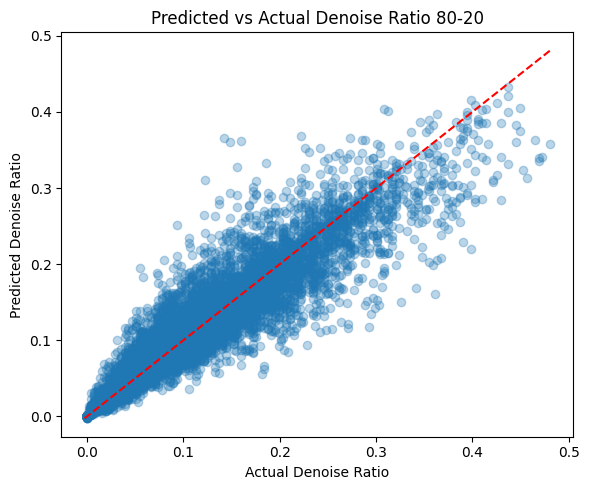

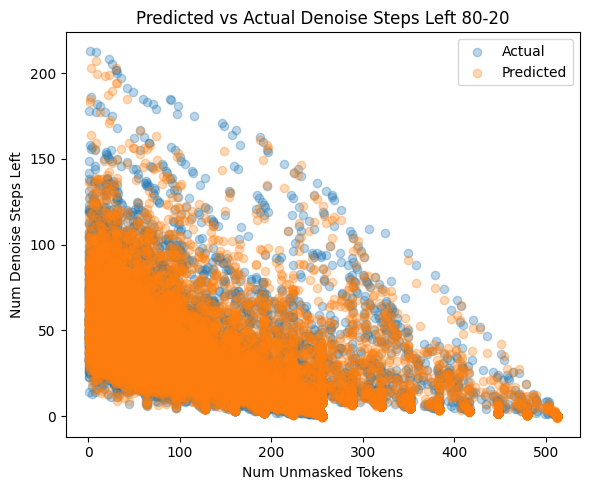

In [11]:
case_model = CaseModel(base_model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    # n_estimators=200,
    # learning_rate=0.1,
    # num_leaves=64,
    num_leaves = 800,
    verbose=-1,
), 
mapping = {
    0.5: 0, 
    0.6: 1, 
    0.7: 2, 
    0.8: 3, 
    0.9: 4, 
}, 
feature="confidence_threshold"
)

train_experiment(case_model, X_train, X_test, y_train, y_test, included_features_T)
predict_benchmark(case_model, X_test, included_features_T)

In [18]:
df_t = copy.deepcopy(df)
df_t["conf_2"] = df_t["confidence_threshold"] ** 2
df_t["conf_3"] = df_t["confidence_threshold"] ** 3
df_t["conf_inv"] = 1 / df_t["confidence_threshold"]
df_t["conf_inv_2"] = 1 / df_t["conf_2"]
X_train, X_test, y_train, y_test = train_test_split_2(df_t[included_features_T + ["output_length", "num_unmasked_tokens", "conf_2", "conf_3", "conf_inv" ,"conf_inv_2"]], df_t["denoise_ratio"], "confidence_threshold", test_size = 0.2, random_state=42)

Additional feature: conf_2
Inferrence: Make 12100 predictions in 20.74122428894043 ms
RMSE (steps): 8.8136
R^2   (steps): 0.9063
Percentage (steps): 0.1416
RMSE (ratio): 0.0239
R^2   (ratio): 0.9071
Percentage (ratio): 0.1466
Average prediction time per sample (single): 2.7355222859658483 ms
Additional feature: conf_3
Inferrence: Make 12100 predictions in 17.713069915771484 ms
RMSE (steps): 8.8136
R^2   (steps): 0.9063
Percentage (steps): 0.1416
RMSE (ratio): 0.0239
R^2   (ratio): 0.9071
Percentage (ratio): 0.1466
Average prediction time per sample (single): 2.783362372847628 ms
Additional feature: conf_inv
Inferrence: Make 12100 predictions in 20.577430725097656 ms
RMSE (steps): 8.8136
R^2   (steps): 0.9063
Percentage (steps): 0.1416
RMSE (ratio): 0.0239
R^2   (ratio): 0.9071
Percentage (ratio): 0.1466
Average prediction time per sample (single): 3.0554015971412345 ms
Additional feature: conf_inv_2
Inferrence: Make 12100 predictions in 18.00394058227539 ms
RMSE (steps): 8.8136
R^2   (

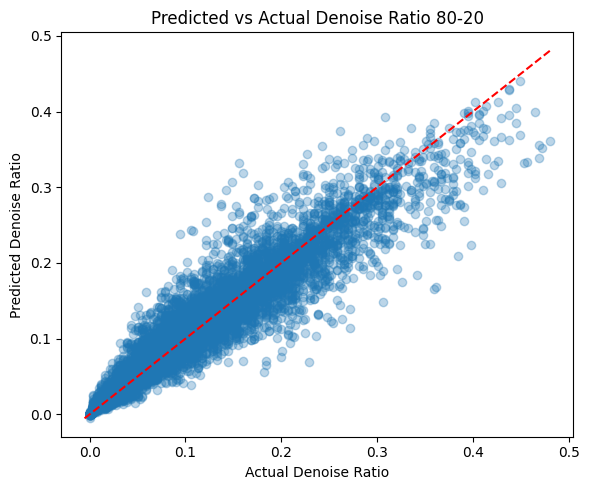

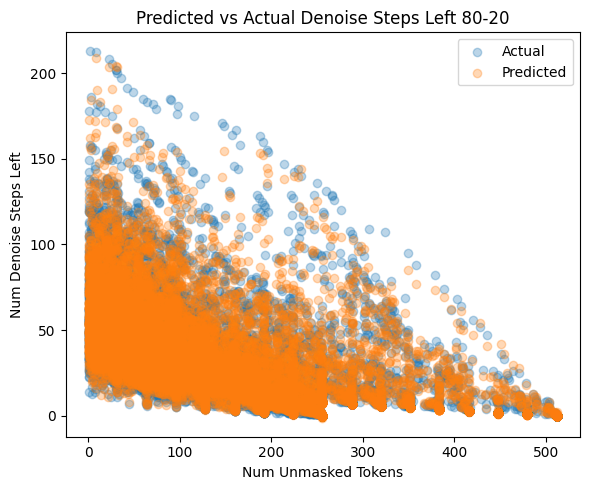

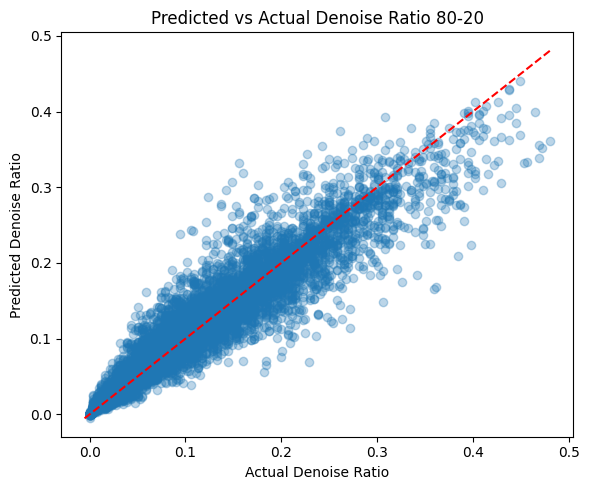

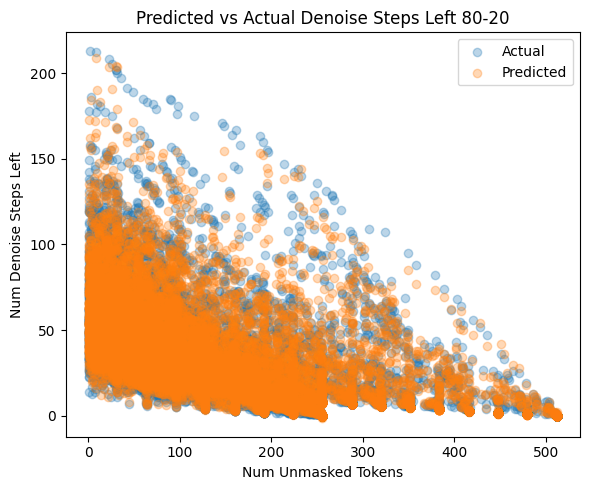

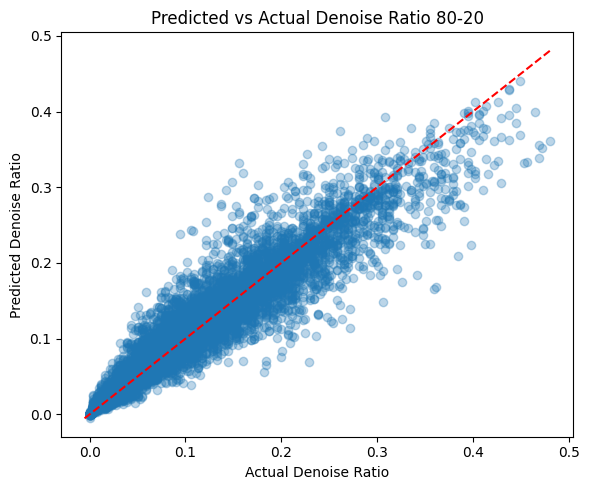

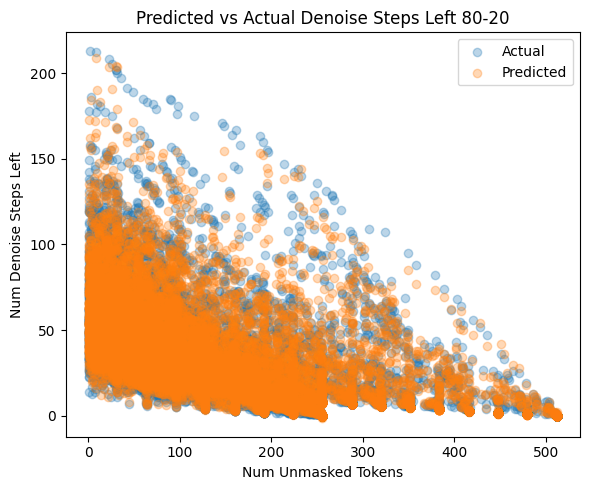

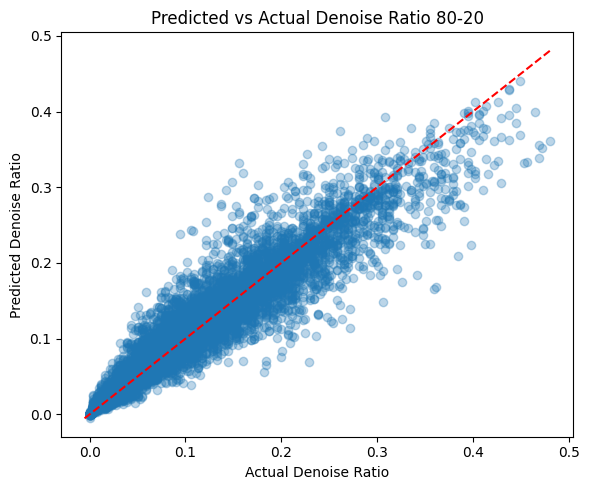

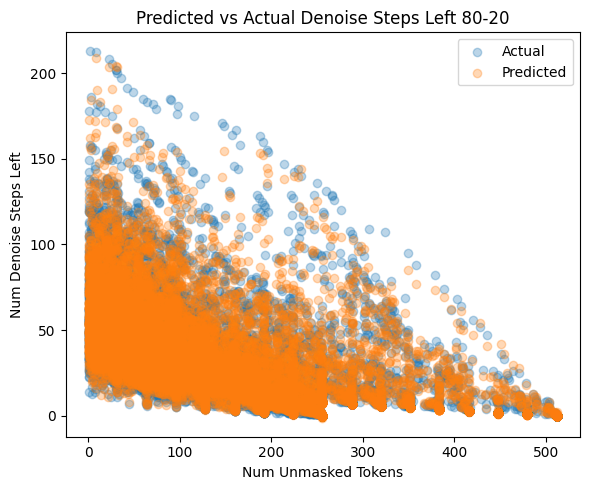

In [19]:

additional_features = ["conf_2", "conf_3", "conf_inv", "conf_inv_2"]

for feature in additional_features: 
    print(f"Additional feature: {feature}")
    model = lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        # n_estimators=200,
        # learning_rate=0.1,
        # num_leaves=64,
        num_leaves = 800,
        verbose=-1,
    )
    train_experiment(model, X_train, X_test, y_train, y_test, included_features_T + [feature])
    predict_benchmark(model, X_test, included_features_T + [feature])

### CURRENT STATE OF THE ART

In [22]:
df_t_2 = copy.deepcopy(df)

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit + transform
encoded = enc.fit_transform(df_t_2[['confidence_threshold']])   # must be 2D

# Turn into DataFrame
encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(['confidence_threshold']))

# Concatenate back if needed
df_encoded = pd.concat([df_t_2.drop(columns=['confidence_threshold']), encoded_df], axis=1)

In [36]:
included_features_T2 = included_features_T[1:] + list(encoded_df.columns)

In [37]:
included_features_T2

['full_unmask_progress',
 'block_progress',
 'block_unmask_progress',
 'full_cur_unmask_progress',
 'mean_confidences',
 'median_confidences',
 'min_confidences',
 'lower_quartile_confidences',
 'higher_quartile_confidences',
 'ewma_5',
 'ewma_10',
 'ewma_20',
 'confidence_threshold_0.5',
 'confidence_threshold_0.6000000000000001',
 'confidence_threshold_0.7000000000000001',
 'confidence_threshold_0.8',
 'confidence_threshold_0.9']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(df_encoded[included_features_T2 + ["output_length", "num_unmasked_tokens"]], df_encoded["denoise_ratio"], test_size = 0.2, random_state=42)

Inferrence: Make 12099 predictions in 23.861408233642578 ms
RMSE (steps): 8.8406
R^2   (steps): 0.9064
Percentage (steps): 0.1473
RMSE (ratio): 0.0244
R^2   (ratio): 0.9037
Percentage (ratio): 0.1529
Average prediction time per sample (single): 2.777808874596721 ms


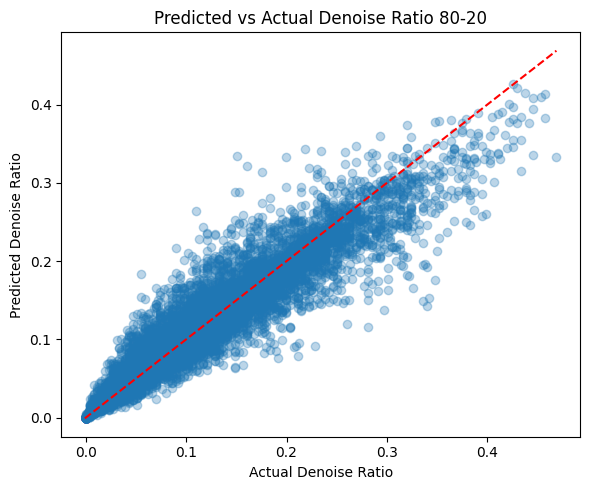

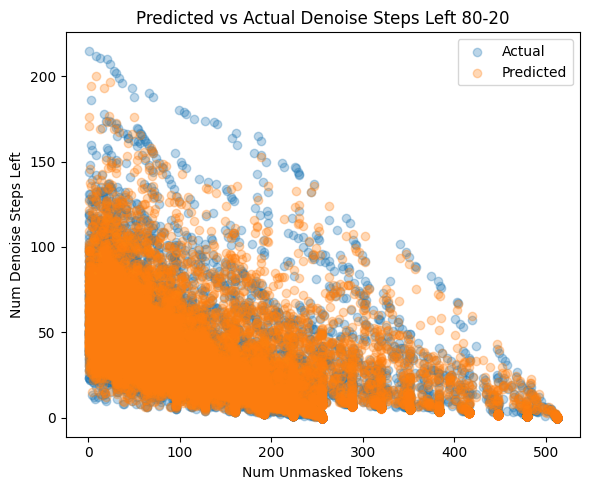

In [41]:
model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    # n_estimators=200,
    # learning_rate=0.1,
    # num_leaves=64,
    num_leaves = 900,
    verbose=-1,
)
train_experiment(model, X_train, X_test, y_train, y_test, included_features_T2)
predict_benchmark(model, X_test, included_features_T2)